# 2D Quasi-Geostrophic model — tutorial

How to drive the integrator in `QG_2D.py`: run it with different parameter
settings, access derived fields (streamfunction, velocity), and visualize
snapshots and bulk diagnostics.

The prognostic variable is the relative vorticity $q$ on a doubly-periodic
$N\times N$ grid; the model solves

$$\frac{\partial q}{\partial t} + J(\psi,q) + \beta\,\frac{\partial\psi}{\partial x}
   = F - \mu\,q - \nu(-\nabla^2)^p q .$$

Make sure `QG_2D.py` is in the same directory as this notebook.

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import os
from IPython.display import Image, display

from QG_2D import QG2D
from visualization import plot_snapshot, animate, plot_energy_spectra

# show animations (set to True to display animations)
show_animations = False

## 1. A single run with the default forced–dissipative settings

`run(...)` integrates the model and returns an `xarray.Dataset` with dims
`(time, y, x)`; the model settings are stored in `ds.attrs`, and passing
`path=...` also writes a netCDF file.

In [44]:
m = QG2D(N=64, beta=0.0, mu=0.1, nu=1e-3, p=2, A=4.0, k_f=4)

if os.path.exists("qg_runs/qg_default.nc"):
    ds = m.load("qg_runs/qg_default.nc")
else:
    q0 = m.random_ic(seed=0, amp=2.0)        # smooth random initial vorticity
    ds = m.run(q0, tf=60, dt=0.01,           # integrate 60 time units, step 0.01
               spinup=40,                    # discard 40 units of spin-up first
               store_every=20,               # keep every 20th step
               path="qg_runs/qg_default.nc")         # also save to netCDF

ds

<xarray.Dataset>
Dimensions:  (time: 301, y: 64, x: 64)
Coordinates:
  * time     (time) float64 0.0 0.2 0.4 0.6 0.8 1.0 ... 59.2 59.4 59.6 59.8 60.0
  * y        (y) float64 0.0 0.09817 0.1963 0.2945 ... 5.89 5.989 6.087 6.185
  * x        (x) float64 0.0 0.09817 0.1963 0.2945 ... 5.89 5.989 6.087 6.185
Data variables:
    q        (time, y, x) float64 5.546 5.268 4.747 3.972 ... 7.948 8.466 8.394
Attributes:
    N:        64
    L:        6.283185307179586
    beta:     0.0
    mu:       0.1
    nu:       0.001
    p:        2
    A:        4.0
    k_f:      4

Snapshot and animation of vorticity

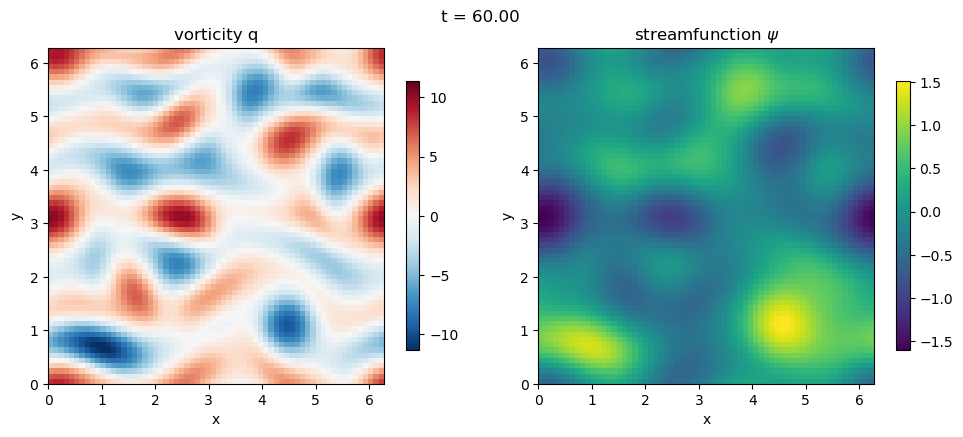

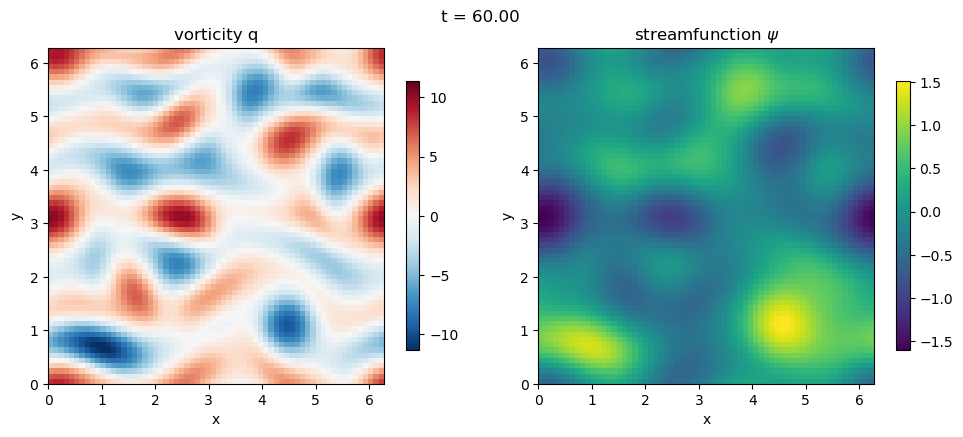

In [45]:
# last time step
plot_snapshot(ds)

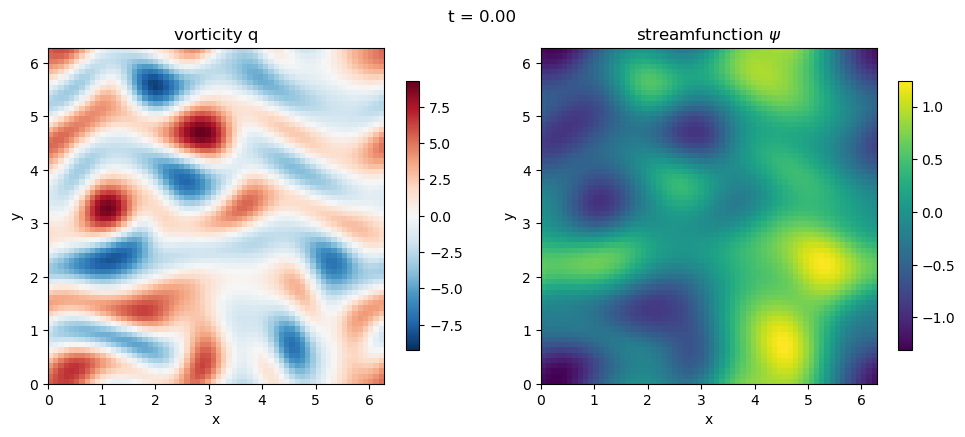

In [46]:
# first time step (after spinup)
plot_snapshot(ds, t_index=0, savepath='plots/snap.png')

In [47]:
# save animation as gif
if not os.path.exists("./plots/animation.gif"):
    animate(ds, savepath='./plots/animation.gif', fps=10)

if show_animations:
    display(Image(filename="./plots/animation.gif"))

Also plot stationary forcing (stationary Kolmogorov forcing)

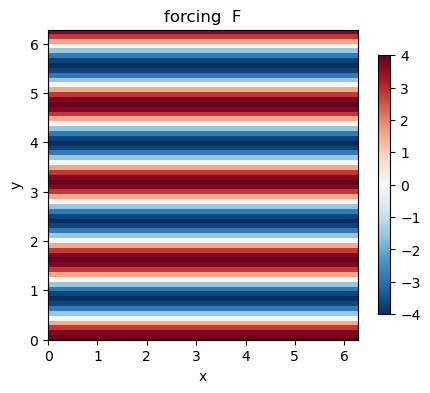

In [48]:
m = QG2D(N=64, A=4.0, k_f=4)          # forcing is fixed at construction

F = np.real(np.fft.ifft2(m.F_hat))   # the stationary forcing field, shape (N, N)
# equivalently: F = m.A * np.cos(m.k_f * m.Y)

extent = [0, m.L, 0, m.L]
fmax = np.abs(F).max()
fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(F.T, cmap="RdBu_r", origin="lower", extent=extent, vmin=-fmax, vmax=fmax)
ax.set_title("forcing  F")
ax.set_xlabel("x"); ax.set_ylabel("y")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

## 2. Bulk diagnostics

Energy $E=\tfrac12\langle|\mathbf{u}|^2\rangle$ and enstrophy
$Z=\tfrac12\langle q^2\rangle$ over the stored trajectory.

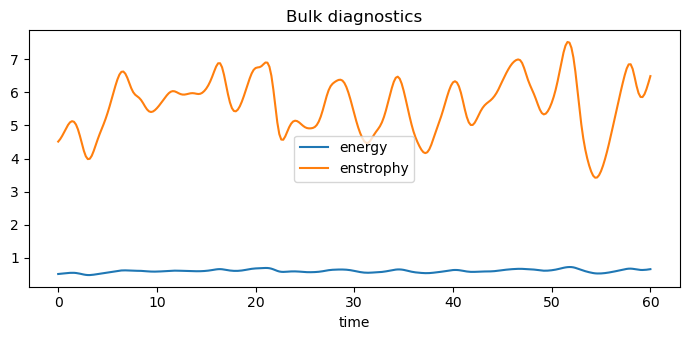

In [49]:
energy = np.array([m.energy(q) for q in ds.q.values])
enstrophy = np.array([m.enstrophy(q) for q in ds.q.values])

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(ds.time, energy, label="energy")
ax.plot(ds.time, enstrophy, label="enstrophy")
ax.set_xlabel("time")
ax.legend()
ax.set_title("Bulk diagnostics")
fig.tight_layout()
plt.show()

## 3. Sensitivity of the QG system

### 3.1 The planetary vorticity gradient `beta`

Larger `beta` drives the flow from isotropic turbulence toward zonal (banded)
structure — Rossby waves and jets.

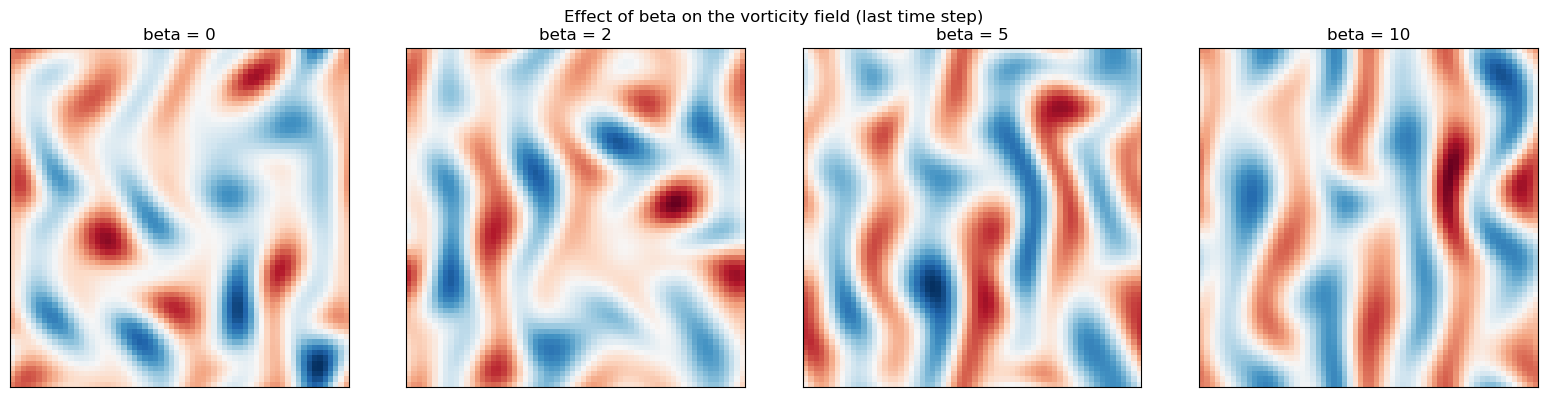

In [50]:
settings_beta = {
    "beta = 0":   dict(beta=0.0),
    "beta = 2":  dict(beta=2.0),
    "beta = 5":  dict(beta=5.0),
    "beta = 10":  dict(beta=10.0),
}

os.makedirs("qg_runs", exist_ok=True)

fig, axes = plt.subplots(1, len(settings_beta), figsize=(4 * len(settings_beta), 4))
for ax, (label, override) in zip(axes, settings_beta.items()):
    path = os.path.join("qg_runs", f"qg_beta_{override['beta']}.nc")
    model = QG2D(N=64, mu=0.1, nu=1e-3, p=2, A=4.0, k_f=4, **override)

    if os.path.exists(path):
        run = model.load(path)                        # reuse the saved simulation
    else:
        run = model.run(model.random_ic(seed=0, amp=2.0),
                        tf=40, dt=0.008, spinup=40, store_every=50,
                        path=path)                    # compute and cache

    field = run.q.isel(time=-1).values
    vmax = np.abs(field).max()
    ax.imshow(field, cmap="RdBu_r", origin="lower", vmin=-vmax, vmax=vmax)
    ax.set_title(label)
    ax.set_xticks([]); ax.set_yticks([])

    # also save animation
    if not os.path.exists(f"./plots/animation_beta_{override['beta']}.gif"):
        animate(run, savepath=f"./plots/animation_beta_{override['beta']}.gif", fps=10)

fig.suptitle("Effect of beta on the vorticity field (last time step)")
fig.tight_layout()
plt.show()

In [51]:
if show_animations:
    for (label, override) in settings_beta.items():
        print(label)
        display(Image(filename=f"./plots/animation_beta_{override['beta']}.gif"))

### 3.2 Forcing wavenumber (`k_f`)

Larger `k_f` increases the number of eddies, however the flow becomes less turbulent

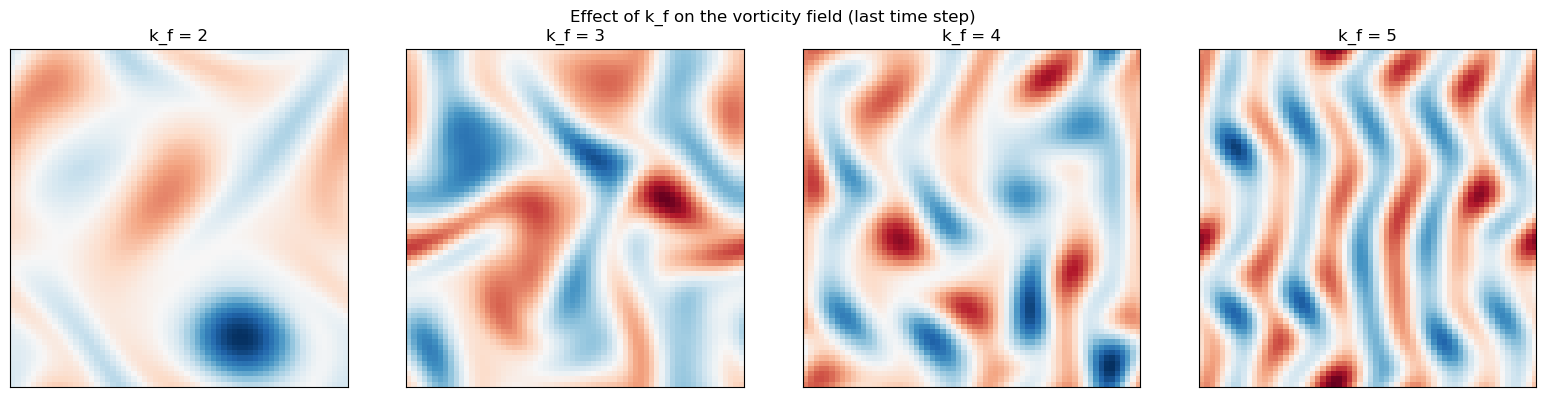

In [52]:
settings_kf = {
    "k_f = 2":  dict(k_f=2.0),
    "k_f = 3":  dict(k_f=3.0),
    "k_f = 4":  dict(k_f=4.0),
    "k_f = 5":  dict(k_f=5.0),
}

os.makedirs("qg_runs", exist_ok=True)

fig, axes = plt.subplots(1, len(settings_kf), figsize=(4 * len(settings_kf), 4))
for ax, (label, override) in zip(axes, settings_kf.items()):
    path = os.path.join("qg_runs", f"qg_k_f_{override['k_f']}.nc")
    model = QG2D(N=64, mu=0.1, nu=1e-3, p=2, A=4.0, beta=0.0, **override)

    if os.path.exists(path):
        run = model.load(path)                        # reuse the saved simulation
    else:
        run = model.run(model.random_ic(seed=0, amp=2.0),
                        tf=40, dt=0.008, spinup=40, store_every=50,
                        path=path)                    # compute and cache

    field = run.q.isel(time=-1).values
    vmax = np.abs(field).max()
    ax.imshow(field, cmap="RdBu_r", origin="lower", vmin=-vmax, vmax=vmax)
    ax.set_title(label)
    ax.set_xticks([]); ax.set_yticks([])

    # also save animation
    if not os.path.exists(f"./plots/animation_k_f_{override['k_f']}.gif"):
        animate(run, savepath=f"./plots/animation_k_f_{override['k_f']}.gif", fps=10)

fig.suptitle("Effect of k_f on the vorticity field (last time step)")
fig.tight_layout()
plt.show()

In [53]:
if show_animations:
    for (label, override) in settings_kf.items():
        print(label)
        display(Image(filename=f"./plots/animation_k_f_{override['k_f']}.gif"))

### 3.3 Forcing amplitude (`A`)

Stronger forcing: more energetic / turbulent flow

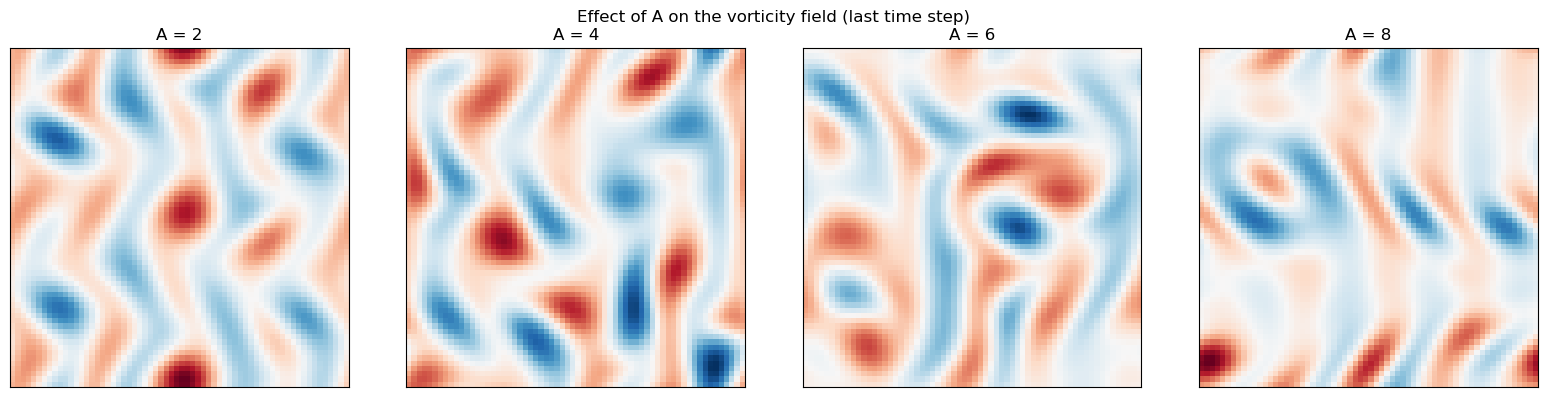

In [54]:
settings_A = {
    "A = 2":  dict(A=2.0),
    "A = 4":  dict(A=4.0),
    "A = 6":  dict(A=6.0),
    "A = 8":  dict(A=8.0),
}

os.makedirs("qg_runs", exist_ok=True)

fig, axes = plt.subplots(1, len(settings_A), figsize=(4 * len(settings_A), 4))
for ax, (label, override) in zip(axes, settings_A.items()):
    path = os.path.join("qg_runs", f"qg_A_{override['A']}.nc")
    model = QG2D(N=64, mu=0.1, nu=1e-3, p=2, k_f=4.0, beta=0.0, **override)

    if os.path.exists(path):
        run = model.load(path)                        # reuse the saved simulation
    else:
        run = model.run(model.random_ic(seed=0, amp=2.0),
                        tf=40, dt=0.008, spinup=40, store_every=50,
                        path=path)                    # compute and cache

    field = run.q.isel(time=-1).values
    vmax = np.abs(field).max()
    ax.imshow(field, cmap="RdBu_r", origin="lower", vmin=-vmax, vmax=vmax)
    ax.set_title(label)
    ax.set_xticks([]); ax.set_yticks([])

    # also save animation
    if not os.path.exists(f"./plots/animation_A_{override['A']}.gif"):
        animate(run, savepath=f"./plots/animation_A_{override['A']}.gif", fps=10)

fig.suptitle("Effect of A on the vorticity field (last time step)")
fig.tight_layout()
plt.show()

In [55]:
if show_animations:
    for (label, override) in settings_A.items():
        print(label)
        display(Image(filename=f"./plots/animation_A_{override['A']}.gif"))

### 3.4 Linear drag coefficient (`mu`)

Weaker drag: energy accumulates at larger scales

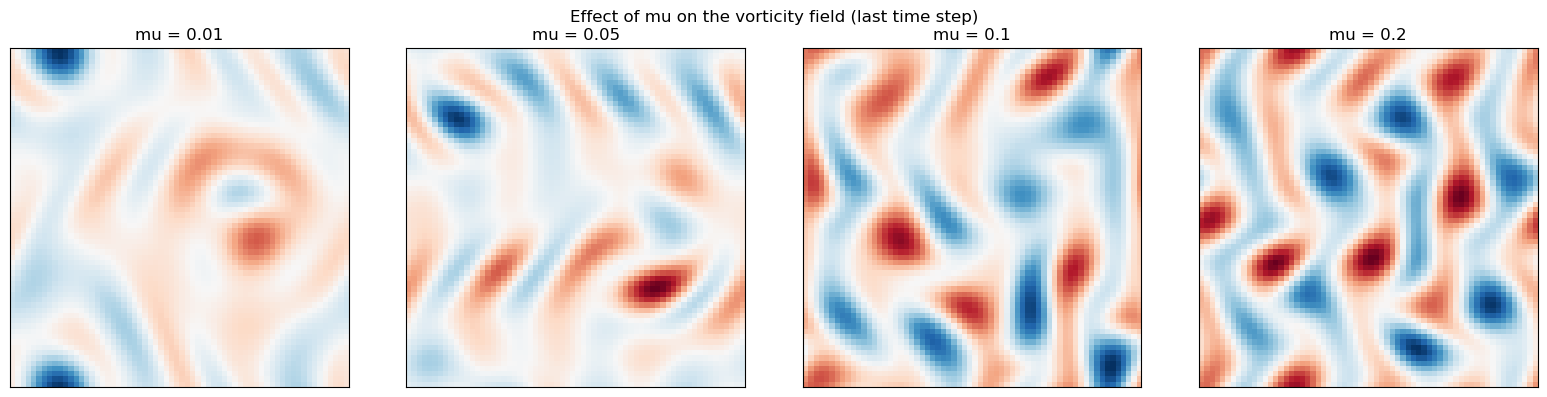

In [56]:
settings_mu = {
    "mu = 0.01":  dict(mu=0.01),
    "mu = 0.05":  dict(mu=0.05),
    "mu = 0.1":  dict(mu=0.1),
    "mu = 0.2":  dict(mu=0.2),
}

os.makedirs("qg_runs", exist_ok=True)

fig, axes = plt.subplots(1, len(settings_mu), figsize=(4 * len(settings_mu), 4))
for ax, (label, override) in zip(axes, settings_mu.items()):
    path = os.path.join("qg_runs", f"qg_mu_{override['mu']}.nc")
    model = QG2D(N=64, A=4.0, nu=1e-3, p=2, k_f=4.0, beta=0.0, **override)

    if os.path.exists(path):
        run = model.load(path)                        # reuse the saved simulation
    else:
        run = model.run(model.random_ic(seed=0, amp=2.0),
                        tf=40, dt=0.008, spinup=40, store_every=50,
                        path=path)                    # compute and cache

    field = run.q.isel(time=-1).values
    vmax = np.abs(field).max()
    ax.imshow(field, cmap="RdBu_r", origin="lower", vmin=-vmax, vmax=vmax)
    ax.set_title(label)
    ax.set_xticks([]); ax.set_yticks([])

    # also save animation
    if not os.path.exists(f"./plots/animation_mu_{override['mu']}.gif"):
        animate(run, savepath=f"./plots/animation_mu_{override['mu']}.gif", fps=10)

fig.suptitle("Effect of mu on the vorticity field (last time step)")
fig.tight_layout()
plt.show()

In [57]:
if show_animations:
    for (label, override) in settings_mu.items():
        print(label)
        display(Image(filename=f"./plots/animation_mu_{override['mu']}.gif"))

### 3.5 Hyperviscosity coefficient (`nu`)

Weaker hyperviscosity: sharper small-scale features

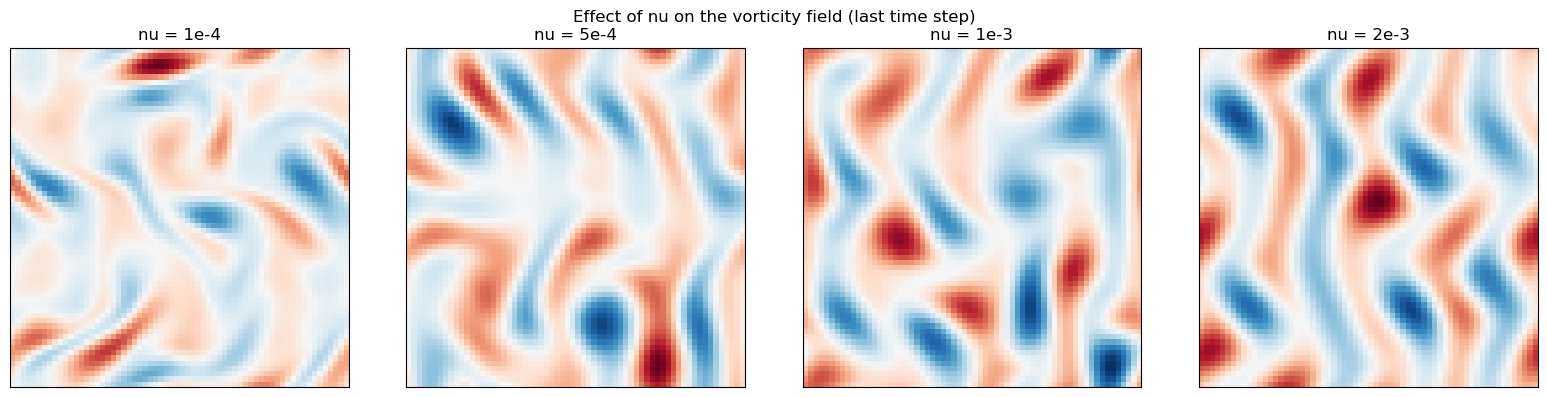

In [58]:
settings_nu = {
    "nu = 1e-4":  dict(nu=1e-4),
    "nu = 5e-4":  dict(nu=5e-4),
    "nu = 1e-3":  dict(nu=1e-3),
    "nu = 2e-3":  dict(nu=2e-3),
}

os.makedirs("qg_runs", exist_ok=True)

fig, axes = plt.subplots(1, len(settings_nu), figsize=(4 * len(settings_nu), 4))
for ax, (label, override) in zip(axes, settings_nu.items()):
    path = os.path.join("qg_runs", f"qg_nu_{override['nu']}.nc")
    model = QG2D(N=64, A=4.0, mu=0.1, p=2, k_f=4.0, beta=0.0, **override)

    if os.path.exists(path):
        run = model.load(path)                        # reuse the saved simulation
    else:
        run = model.run(model.random_ic(seed=0, amp=2.0),
                        tf=40, dt=0.008, spinup=40, store_every=50,
                        path=path)                    # compute and cache

    field = run.q.isel(time=-1).values
    vmax = np.abs(field).max()
    ax.imshow(field, cmap="RdBu_r", origin="lower", vmin=-vmax, vmax=vmax)
    ax.set_title(label)
    ax.set_xticks([]); ax.set_yticks([])

    # also save animation
    if not os.path.exists(f"./plots/animation_nu_{override['nu']}.gif"):
        animate(run, savepath=f"./plots/animation_nu_{override['nu']}.gif", fps=10)

fig.suptitle("Effect of nu on the vorticity field (last time step)")
fig.tight_layout()
plt.show()

In [59]:
if show_animations:
    for (label, override) in settings_nu.items():
        print(label)
        display(Image(filename=f"./plots/animation_nu_{override['nu']}.gif"))

### 3.6 Spatial resolution (`N`)

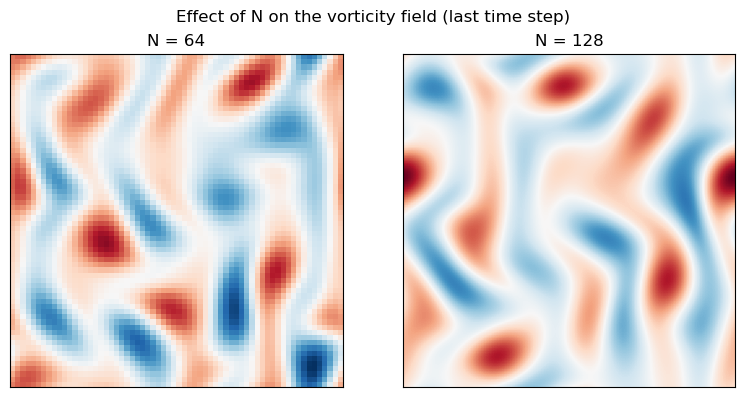

In [60]:
settings_N = {
    "N = 64":  dict(N=64),
    "N = 128":  dict(N=128),
}

os.makedirs("qg_runs", exist_ok=True)

fig, axes = plt.subplots(1, len(settings_N), figsize=(4 * len(settings_N), 4))
for ax, (label, override) in zip(axes, settings_N.items()):
    path = os.path.join("qg_runs", f"qg_N_{override['N']}.nc")
    model = QG2D(A=4.0, mu=0.1, nu=1e-3, p=2, k_f=4.0, beta=0.0, **override)

    if os.path.exists(path):
        run = model.load(path)                        # reuse the saved simulation
    else:
        run = model.run(model.random_ic(seed=0, amp=2.0),
                        tf=40, dt=0.008, spinup=40, store_every=50,
                        path=path)                    # compute and cache

    field = run.q.isel(time=-1).values
    vmax = np.abs(field).max()
    ax.imshow(field, cmap="RdBu_r", origin="lower", vmin=-vmax, vmax=vmax)
    ax.set_title(label)
    ax.set_xticks([]); ax.set_yticks([])

    # also save animation
    if not os.path.exists(f"./plots/animation_N_{override['N']}.gif"):
        animate(run, savepath=f"./plots/animation_N_{override['N']}.gif", fps=10)

fig.suptitle("Effect of N on the vorticity field (last time step)")
fig.tight_layout()
plt.show()

In [61]:
if show_animations:
    for (label, override) in settings_N.items():
        print(label)
        display(Image(filename=f"./plots/animation_N_{override['N']}.gif"))

## 4. Investigate energy spectra

## Energy pathways and spectral controls in the 2-D QG model

We consider the barotropic single-layer QG system in vorticity form:

$$
\frac{\partial q}{\partial t}
+ J(\psi,q)
=
f
-\mu q
-\nu(-\nabla^2)^p q,
$$

where

$$
q = \nabla^2 \psi,
\qquad
u = -\frac{\partial \psi}{\partial y},
\qquad
v = \frac{\partial \psi}{\partial x}.
$$

Here, $q$ is relative vorticity, $\psi$ is the streamfunction, $f$ is the forcing, $\mu$ is the linear-drag coefficient, and $\nu$ is the viscosity or hyperviscosity coefficient. The exponent $p=1$ corresponds to ordinary viscosity, while $p>1$ corresponds to hyperviscosity.

### Kinetic-energy spectrum

The domain-mean kinetic energy is

$$
E =
\frac{1}{2}
\left\langle u^2 + v^2 \right\rangle
=
\frac{1}{2}
\left\langle |\nabla \psi|^2 \right\rangle.
$$

In Fourier space, each mode is represented by a horizontal-wavenumber pair $(k_x,k_y)$, whose magnitude is

$$
K = \sqrt{k_x^2 + k_y^2}.
$$

The kinetic energy of one Fourier mode is

$$
E_{k_x,k_y}
=
\frac{1}{2} K^2 |\hat{\psi}_{k_x,k_y}|^2
=
\frac{1}{2}
\frac{|\hat{q}_{k_x,k_y}|^2}{K^2}.
$$

The isotropic kinetic-energy spectrum $E(k)$ is obtained by summing the energy from all Fourier modes whose magnitude lies inside a shell around $k$:

$$
E(k)
=
\sum_{k-\Delta k/2 < K \leq k+\Delta k/2}
E_{k_x,k_y}.
$$

Thus, $E(k)$ shows how the total kinetic energy is distributed among spatial scales:

- small $k$: large-scale flow structures;
- large $k$: small-scale eddies and vorticity filaments.

The total kinetic energy is recovered by summing over spectral shells:

$$
E = \sum_{k \geq 1} E(k).
$$

### Energy injection, transfer, and dissipation

The forcing injects energy and enstrophy near the prescribed forcing wavenumber

$$
k_f = 4.
$$

The nonlinear Jacobian term $J(\psi,q)$ transfers energy and enstrophy between scales but does not create or destroy them in the ideal system.

The expected behaviour is the dual cascade of two-dimensional turbulence:

$$
\text{Energy:}
\qquad
k_f \rightarrow k < k_f,
$$

$$
\text{Enstrophy:}
\qquad
k_f \rightarrow k > k_f.
$$

Therefore, energy tends to move from the forcing scale toward larger spatial scales, while enstrophy tends to move toward smaller spatial scales.

In a statistically steady state, the time-mean energy injection should balance the two sinks:

$$
\overline{\epsilon}_{\mathrm{in}}
\approx
\overline{\epsilon}_{\mathrm{drag}}
+
\overline{\epsilon}_{\mathrm{hyper}}.
$$

### Role of linear drag

The linear-drag term is

$$
-\mu q.
$$

It damps every Fourier mode at a rate proportional to $\mu$:

$$
\frac{dE_k}{dt}\bigg|_{\mathrm{drag}}
=
-2\mu E_k.
$$

Thus, linear drag acts on all scales directly. However, it is particularly important at large scales because energy is transferred upscale, whereas hyperviscosity has very little effect at low wavenumbers.

A smaller $\mu$ allows energy to accumulate near the domain scale, especially close to $k=1$. A larger $\mu$ removes this large-scale energy more efficiently and suppresses the formation of large coherent structures.

Linear drag can also affect high-wavenumber energy indirectly: stronger drag reduces the overall flow amplitude and weakens nonlinear transfers across scales. However, it is not strongly scale selective.

### Role of viscosity and hyperviscosity

The viscous or hyperviscous term is

$$
-\nu(-\nabla^2)^p q.
$$

In Fourier space, its damping rate is

$$
\nu K^{2p}.
$$

The corresponding kinetic-energy tendency of one Fourier mode is

$$
\frac{dE_K}{dt}\bigg|_{\mathrm{hyper}}
=
-2\nu K^{2p} E_K.
$$

This makes hyperviscosity strongly scale selective:

- At low wavenumbers, $K$ is small, so hyperviscosity is weak.
- At high wavenumbers, $K$ is large, so hyperviscosity rapidly removes energy and enstrophy.

Hyperviscosity is therefore the main small-scale sink. It limits the downscale enstrophy cascade, prevents excessive accumulation near the grid scale, and improves numerical stability.

Reducing $\nu$ allows energy and enstrophy to extend to higher wavenumbers, corresponding to finer eddies and sharper vorticity gradients. Increasing $\nu$ shifts the dissipation cutoff toward lower wavenumbers and produces a smoother flow.

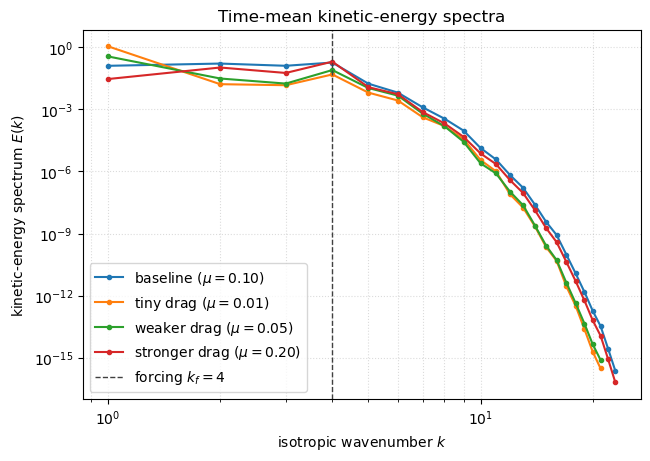

In [ ]:
# test of varying drag coefficient mu
ds_base_drag = model.load(os.path.join("qg_runs", "qg_mu_0.1.nc"))
ds_tiny_drag = model.load(os.path.join("qg_runs", "qg_mu_0.01.nc"))
ds_low_drag = model.load(os.path.join("qg_runs", "qg_mu_0.05.nc"))
ds_high_drag = model.load(os.path.join("qg_runs", "qg_mu_0.2.nc"))

fig, ax, spectra = plot_energy_spectra(
    [ds_base_drag, ds_tiny_drag, ds_low_drag, ds_high_drag],
    labels=[
        r"baseline ($\mu=0.10$)",
        r"tiny drag ($\mu=0.01$)",
        r"weaker drag ($\mu=0.05$)",
        r"stronger drag ($\mu=0.20$)",
    ],
    time_start=20.0,   # exclude remaining transient
    max_frames=200,    # optional
    savepath="plots/energy_spectra_drag_sensitivity.png",
)
plt.show()

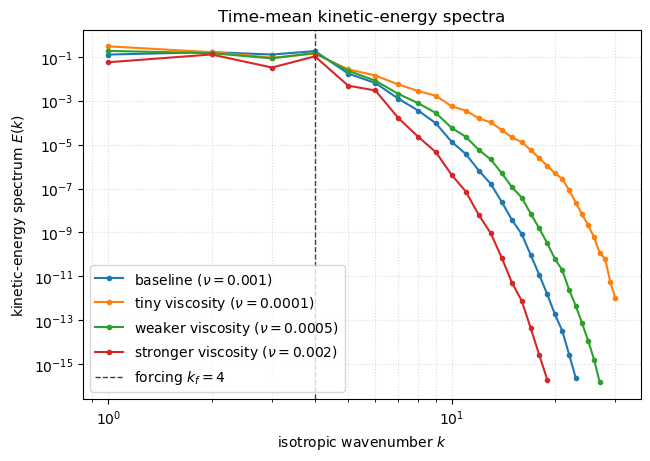

In [ ]:
# test of varying viscosity nu
ds_base_viscosity = model.load(os.path.join("qg_runs", "qg_nu_0.001.nc"))
ds_tiny_viscosity = model.load(os.path.join("qg_runs", "qg_nu_0.0001.nc"))
ds_low_viscosity = model.load(os.path.join("qg_runs", "qg_nu_0.0005.nc"))
ds_high_viscosity = model.load(os.path.join("qg_runs", "qg_nu_0.002.nc"))

fig, ax, spectra = plot_energy_spectra(
    [ds_base_viscosity, ds_tiny_viscosity, ds_low_viscosity, ds_high_viscosity],
    labels=[
        r"baseline ($\nu=0.001$)",
        r"tiny viscosity ($\nu=0.0001$)",
        r"weaker viscosity ($\nu=0.0005$)",
        r"stronger viscosity ($\nu=0.002$)",
    ],
    time_start=20.0,   # exclude remaining transient
    max_frames=200,    # optional
    savepath="plots/energy_spectra_viscosity_sensitivity.png",
)
plt.show()

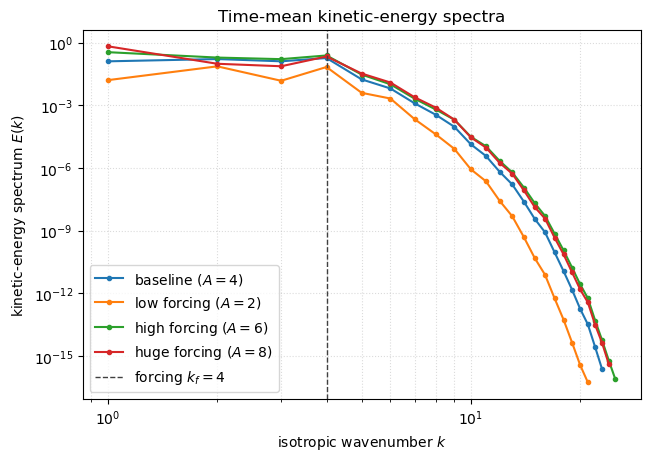

In [65]:
# test of varying forcing amplitude A
ds_base_forcing = model.load(os.path.join("qg_runs", "qg_A_4.0.nc"))
ds_low_forcing = model.load(os.path.join("qg_runs", "qg_A_2.0.nc"))
ds_high_forcing = model.load(os.path.join("qg_runs", "qg_A_6.0.nc"))
ds_huge_forcing = model.load(os.path.join("qg_runs", "qg_A_8.0.nc"))

fig, ax, spectra = plot_energy_spectra(
    [ds_base_forcing, ds_low_forcing, ds_high_forcing, ds_huge_forcing],
    labels=[
        r"baseline ($A=4$)",
        r"low forcing ($A=2$)",
        r"high forcing ($A=6$)",
        r"huge forcing ($A=8$)",
    ],
    time_start=20.0,   # exclude remaining transient
    max_frames=200,    # optional
    savepath="plots/energy_spectra_forcing_sensitivity.png",
)
plt.show()